# Практическое задание «Поиск выбросов»

## Шаблон для выполнения

### Часть 1. Выявление и визуализация выбросов

В этом задании вы будете работать с реальным датасетом, в котором содержится информация о более чем 50 000 бриллиантах. У каждого бриллианта есть несколько характеристик:

• **carat**: вес бриллианта. Более крупные бриллианты, как правило, дороже.

• **cut**: качество огранки. Измеряется по градации качества: "Fair", "Good", "Very Good",
"Premium", "Ideal".

• **color**: оценка цвета бриллианта. Ранжируется от "J" (худшая) to "D" (лучшая).

• **clarity**: чистота бриллианта. Описывается кодом (по возрастанию качества): "I1" (худшая), "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF" (лучшая).

• **price**: цена бриллианта в долларах США.

Измерения:

• **x, y, z**, длина, ширина и глубина в мм

• Глубина и площадка - это отношения (в %)

• **depth** = 2 z / (x+y)

• **table** = ширина верха / наибольшая ширина

![image.png](https://u.netology.ru/backend/uploads/lms/content_assets/file/14718/tg_image_378460715.png)

In [207]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

diamonds = sns.load_dataset("diamonds", cache=True, data_home=None)
diamonds.head(5)



,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


1.1. Загрузите файл `diamonds.csv` из библиотеки seaborn. Проведите предварительный анализ:

 - Получите базовые статистики датафрейма.
 - Найдите топ-3 столбца с наибольшим количеством пропусков.
 - Посмотрите уникальные значения в столбцах `carat`, `depth`, `table` и `price`. Есть ли там странные значения?
 - Для каждой из четырх переменных постройте гистограмму и ящик с усами (boxplot).

*Объясните природу выбросов: являются ли они естественными или синтетическими?*

Размер: (53940, 10)

              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     43.000000     43.000000    326.000000      0.000000   
25%        0.400000     61.000000     56.000000    950.000000      4.710000   
50%        0.700000     61.800000     57.000000   2401.000000      5.700000   
75%        1.040000     62.500000     59.000000   5324.250000      6.540000   
max        5.010000     79.000000     95.000000  18823.000000     10.740000   

                  y             z  
count  53940.000000  53940.000000  
mean       5.734526      3.538734  
std        1.142135      0.705699  
min        0.000000      0.000000  
25%        4.720000      2.910000  
50%        5.710000      3.530000  
75%        6.54

/var/folders/5v/0vkb__lj78l6_0j2wqd89c0r0000gn/T/ipykernel_31810/152221808.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if missing[0] > 0:


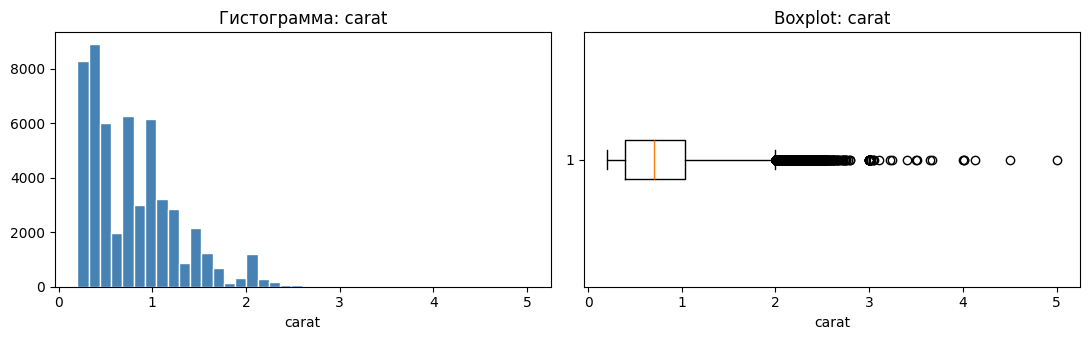

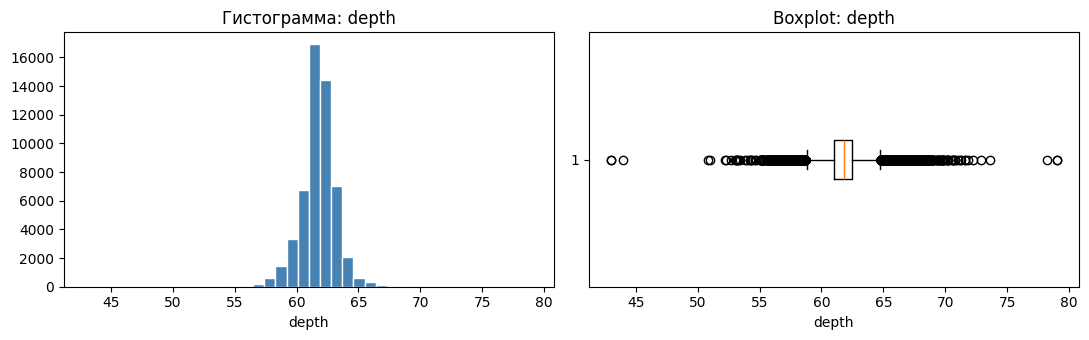

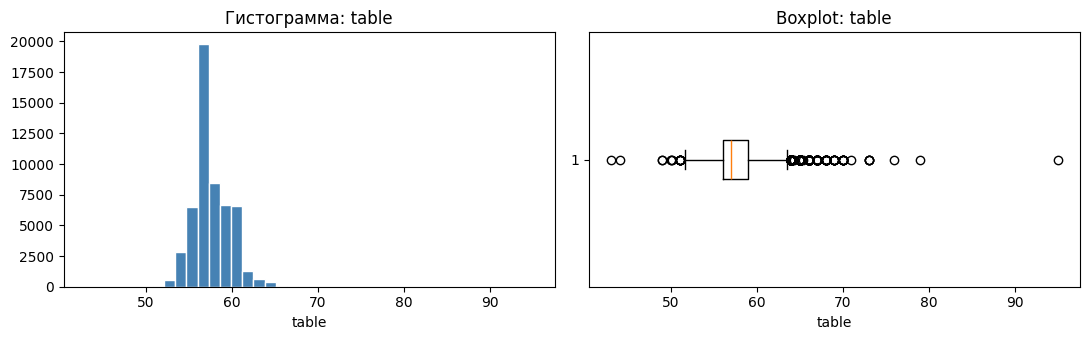

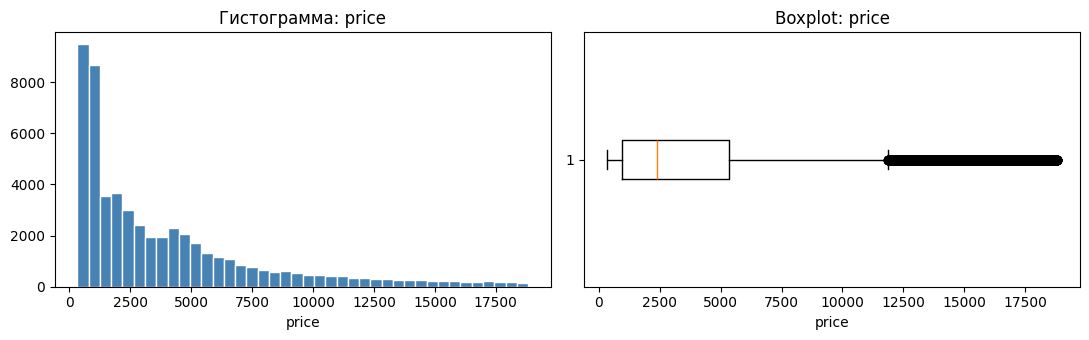

Природа выбросов (кратко):
- carat/price: длинный правый хвост — часто ЕСТЕСТВЕННЫЕ (крупные/дорогие камни редки, но реальны).
- depth/table: экстремумы % — часто СИНТЕТИЧЕСКИЕ/ошибки измерения или ввода.
- x,y,z = 0 — точно ошибочные (синтетические) записи.


In [208]:
# базовые статистики
print("Размер:", diamonds.shape)
print()
print(diamonds.describe()) # Универсальная функция для вывода общей информации по таблице
print()

# пропуски: топ-3 столбца (в diamonds обычно 0 пропусков)
missing = diamonds.isna().sum().sort_values(ascending=False)
if missing[0] > 0:
    print("Пропуски по столбцам:")
    print(missing)
    print()
    print("Топ-3 по числу пропусков:")
    print(missing.head(3))
    print()
else:
    print("Нет пропусков")
    print()

print("потенциальные аномальные значения")
for col in ["carat", "depth", "table", "price"]:
    print("---", col, "---")
    print("min =", diamonds[col].min(), "max =", diamonds[col].max())
    print("nunique =", diamonds[col].nunique())
print()

# нулевые размеры — физически невозможны (синтетические ошибки)
print("Строк с x==0 или y==0 или z==0:", ((diamonds["x"] == 0) | (diamonds["y"] == 0) | (diamonds["z"] == 0)).sum())

# гистограммы и boxplot для 4 переменных
cols = ["carat", "depth", "table", "price"]

for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

    axes[0].hist(diamonds[col], bins=40, color="steelblue", edgecolor="white")
    axes[0].set_title("Гистограмма: " + col)
    axes[0].set_xlabel(col)

    axes[1].boxplot(diamonds[col], vert=False)
    axes[1].set_title("Boxplot: " + col)
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

print(
    "Природа выбросов (кратко):\n"
    "- carat/price: длинный правый хвост — часто ЕСТЕСТВЕННЫЕ (крупные/дорогие камни редки, но реальны).\n"
    "- depth/table: экстремумы % — часто СИНТЕТИЧЕСКИЕ/ошибки измерения или ввода.\n"
    "- x,y,z = 0 — точно ошибочные (синтетические) записи."
)



1.2. Обучите регрессионную модель предсказания цены бриллианта в зависимости от значений веса (в каратах), площадки и глубины.

In [209]:
# признаки: вес, площадка (table), глубина (depth) -> цена
feature_names = ["carat", "table", "depth"]
target_name = "price"

X = diamonds[feature_names].copy()
y = diamonds[target_name].copy()

# разделение данные для примера и обучения
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_before = LinearRegression()
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)

mae_before = mean_absolute_error(y_test, y_pred_before)
rmse_before = np.sqrt(mean_squared_error(y_test, y_pred_before))
r2_before = r2_score(y_test, y_pred_before)

print("Модель ДО очистки выбросов")
print("MAE  =", round(mae_before, 2))
print("RMSE =", round(rmse_before, 2))
print("R2   =", round(r2_before, 4))
print()
print("Коэффициенты:", dict(zip(feature_names, model_before.coef_.round(2))))
print("Свободный член:", round(model_before.intercept_, 2))



Модель ДО очистки выбросов
MAE  = 994.74
RMSE = 1527.71
R2   = 0.8532

Коэффициенты: {'carat': np.float64(7873.05), 'table': np.float64(-106.42), 'depth': np.float64(-150.41)}
Свободный член: 13056.32


### Шаг 2. Обработка признаков

2.1. Реализуйте модельный метод для анализа выбросов.
- Постройте линейную модель для описания данных
- Визуализируйте предсказания

*Определите выбросы по графику предсказаний. Где модель ошибается сильнее всего?*

In [210]:
# модельный метод: учим линию price ~ carat+table+depth на ВСЕХ данных,
# точки с очень большой ошибкой считаем выбросами

X_all = diamonds[feature_names].values
y_all = diamonds[target_name].values

model = LinearRegression()
model.fit(X_all, y_all)

y_pred = model.predict(X_all)
residuals = y_all - y_pred

# порог: 3 стандартных отклонения остатков
threshold = 3 * residuals.std()

# True = выброс
outliers_model = np.abs(residuals) > threshold

print("Порог |остатка| >", round(threshold, 2))
print("Выбросов (модельный метод):", int(outliers_model.sum()))
print("Доля:", round(100 * outliers_model.mean(), 2), "%")



Порог |остатка| > 4578.11
Выбросов (модельный метод): 1227
Доля: 2.27 %


Визуализируйте предсказанную линию на графике и определите выбросы.

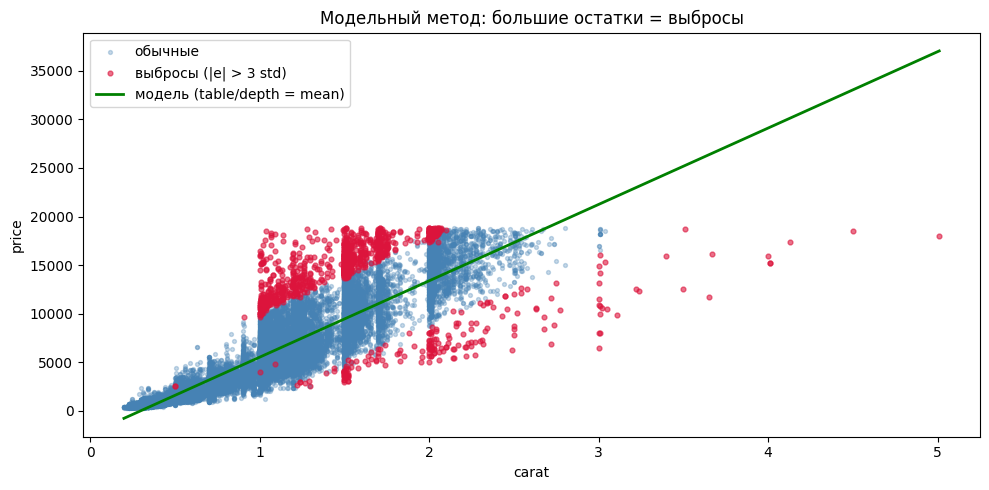

Где модель ошибается сильнее: чаще на очень крупных carat и нетипичных ценах (дорого при малом весе / дёшево при большом) и на экстремальных depth/table.


In [211]:
# по оси X — carat (главный признак цены), по Y — price
plt.figure(figsize=(10, 5))

# обычные точки
plt.scatter(
    diamonds.loc[~outliers_model, "carat"],
    diamonds.loc[~outliers_model, "price"],
    s=8,
    alpha=0.3,
    c="steelblue",
    label="обычные",
)

# выбросы
plt.scatter(
    diamonds.loc[outliers_model, "carat"],
    diamonds.loc[outliers_model, "price"],
    s=12,
    alpha=0.6,
    c="crimson",
    label="выбросы (|e| > 3 std)",
)

# линия «типичной» цены vs carat при средних table и depth
carat_line = np.linspace(diamonds["carat"].min(), diamonds["carat"].max(), 100)
table_mean = diamonds["table"].mean()
depth_mean = diamonds["depth"].mean()
X_line = np.column_stack(
    [
        carat_line,
        np.full(100, table_mean),
        np.full(100, depth_mean),
    ]
)
price_line = model.predict(X_line)
plt.plot(carat_line, price_line, color="green", linewidth=2, label="модель (table/depth = mean)")

plt.xlabel("carat")
plt.ylabel("price")
plt.title("Модельный метод: большие остатки = выбросы")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Где модель ошибается сильнее: чаще на очень крупных carat и нетипичных ценах "
    "(дорого при малом весе / дёшево при большом) и на экстремальных depth/table."
)



2.2. Реализуйте метод опорных векторов (SVM) для поиска выбросов.

In [ ]:
# SVM (облако точек) чувствителен к масштабу — стандартизируем признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# nu - ожидаемая доля выбросов (5%)
# sample_size - на сколькои точках учим, можно не на всех для скороси
rng = np.random.RandomState(42)
sample_size = 8000
nu_percent=0.05
sample_idx = rng.choice(X_scaled.shape[0], size=sample_size, replace=False)

ocsvm = OneClassSVM(kernel="rbf", nu=nu_percent, gamma="scale")
ocsvm.fit(X_scaled[sample_idx])

# 1 = норма, -1 = выброс
pred_svm = ocsvm.predict(X_scaled)
outliers_svm = pred_svm == -1

print("One-Class SVM")
print("Выбросов:", int(outliers_svm.sum()))
print("Доля:", round(100 * outliers_svm.mean(), 2), "%")



One-Class SVM
Выбросов: 2684
Доля: 4.98 %


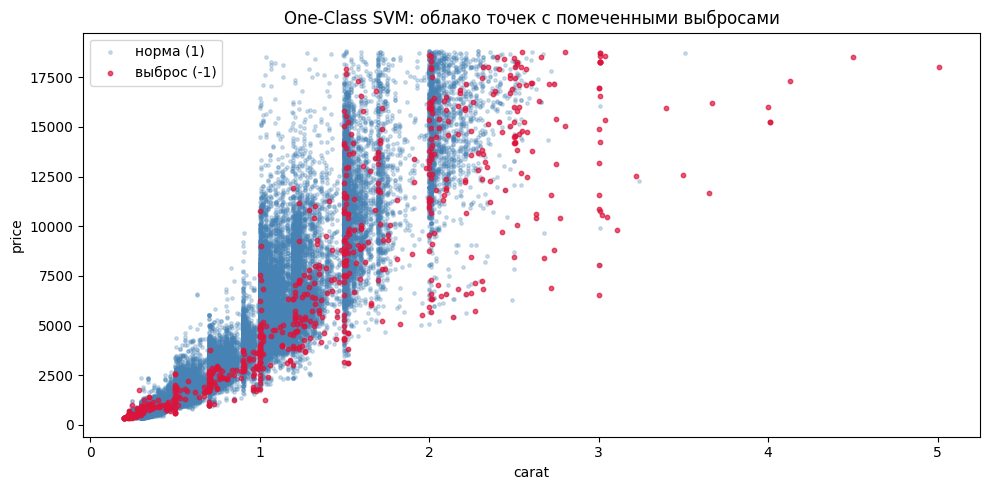

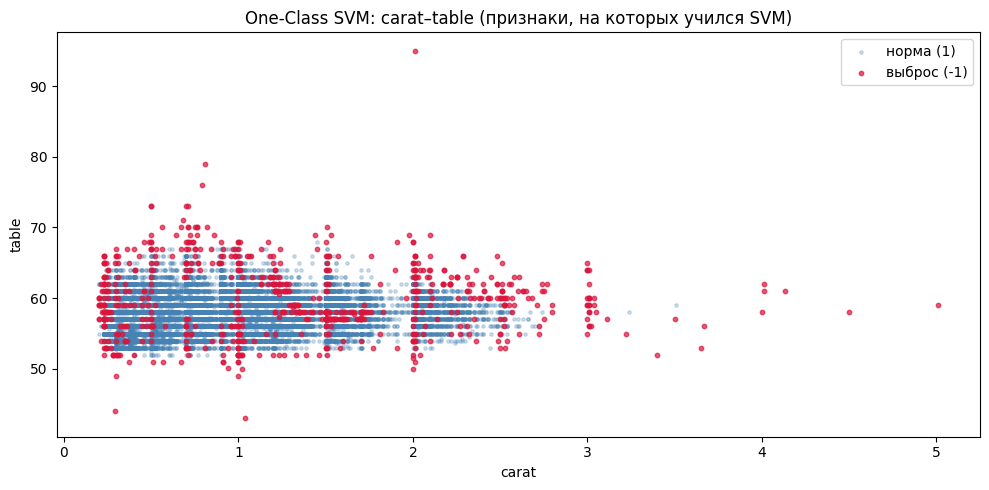

In [213]:
# облако точек: carat–price, красным — выбросы One-Class SVM
plt.figure(figsize=(10, 5))

plt.scatter(
    diamonds.loc[~outliers_svm, "carat"],
    diamonds.loc[~outliers_svm, "price"],
    s=6,
    alpha=0.25,
    c="steelblue",
    label="норма (1)",
)

plt.scatter(
    diamonds.loc[outliers_svm, "carat"],
    diamonds.loc[outliers_svm, "price"],
    s=10,
    alpha=0.7,
    c="crimson",
    label="выброс (-1)",
)

plt.xlabel("carat")
plt.ylabel("price")
plt.title("One-Class SVM: облако точек с помеченными выбросами")
plt.legend()
plt.tight_layout()
plt.show()

# то же в пространстве двух признаков модели (table vs carat)
plt.figure(figsize=(10, 5))

plt.scatter(
    diamonds.loc[~outliers_svm, "carat"],
    diamonds.loc[~outliers_svm, "table"],
    s=6,
    alpha=0.25,
    c="steelblue",
    label="норма (1)",
)

plt.scatter(
    diamonds.loc[outliers_svm, "carat"],
    diamonds.loc[outliers_svm, "table"],
    s=10,
    alpha=0.7,
    c="crimson",
    label="выброс (-1)",
)

plt.xlabel("carat")
plt.ylabel("table")
plt.title("One-Class SVM: carat–table (признаки, на которых учился SVM)")
plt.legend()
plt.tight_layout()
plt.show()


2.3. Реализуйте алгоритм Isolation Forest

In [214]:
iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,  # ожидаем ~5% аномалий
    random_state=42,
    n_jobs=-1,
)
# fit_predict сразу даёт метки 1 / -1
pred_iso = iso.fit_predict(X_scaled)
outliers_iso = pred_iso == -1

print("Isolation Forest")
print("Выбросов:", int(outliers_iso.sum()))
print("Доля:", round(100 * outliers_iso.mean(), 2), "%")



Isolation Forest
Выбросов: 2697
Доля: 5.0 %


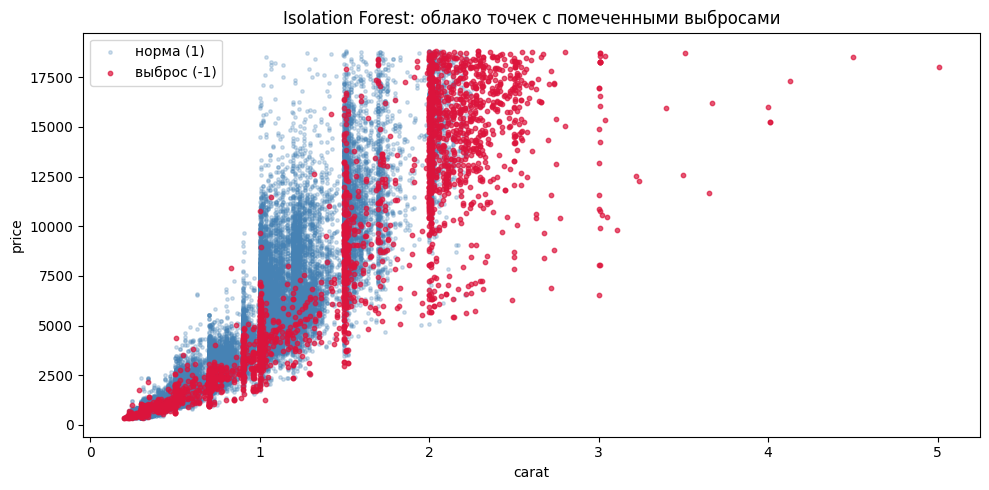

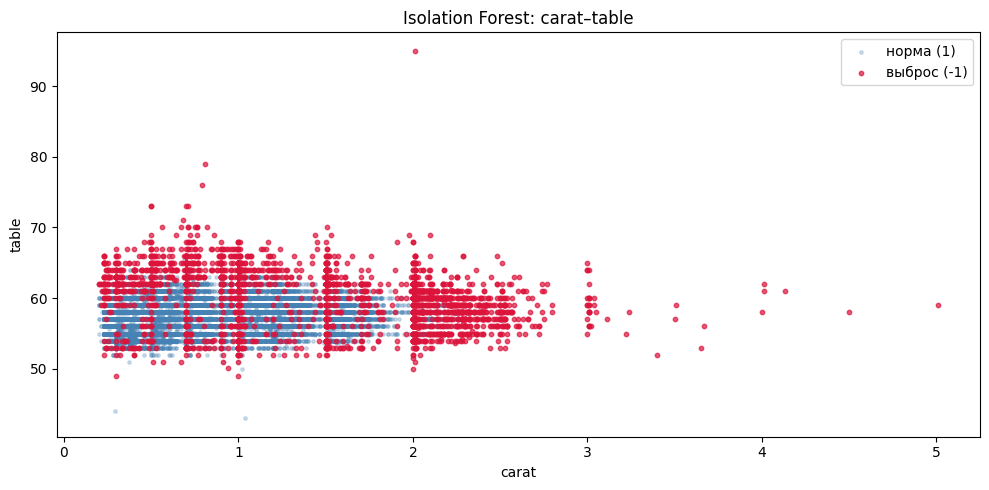

In [215]:
# облако точек: carat–price, красным — выбросы Isolation Forest
plt.figure(figsize=(10, 5))

plt.scatter(
    diamonds.loc[~outliers_iso, "carat"],
    diamonds.loc[~outliers_iso, "price"],
    s=6,
    alpha=0.25,
    c="steelblue",
    label="норма (1)",
)

plt.scatter(
    diamonds.loc[outliers_iso, "carat"],
    diamonds.loc[outliers_iso, "price"],
    s=10,
    alpha=0.7,
    c="crimson",
    label="выброс (-1)",
)

plt.xlabel("carat")
plt.ylabel("price")
plt.title("Isolation Forest: облако точек с помеченными выбросами")
plt.legend()
plt.tight_layout()
plt.show()

# carat–table — пространство признаков модели
plt.figure(figsize=(10, 5))

plt.scatter(
    diamonds.loc[~outliers_iso, "carat"],
    diamonds.loc[~outliers_iso, "table"],
    s=6,
    alpha=0.25,
    c="steelblue",
    label="норма (1)",
)

plt.scatter(
    diamonds.loc[outliers_iso, "carat"],
    diamonds.loc[outliers_iso, "table"],
    s=10,
    alpha=0.7,
    c="crimson",
    label="выброс (-1)",
)

plt.xlabel("carat")
plt.ylabel("table")
plt.title("Isolation Forest: carat–table")
plt.legend()
plt.tight_layout()
plt.show()


2.4. Сравните работу методов: какой из них предпочтительнее для вашей задачи?

2.5. Удалите выбросы выбранным методом

In [216]:
# сравнение, сколько выбросов нашёл каждый метод
print("Число выбросов:")
print("  модельный (остатки):", int(outliers_model.sum()))
print("  One-Class SVM:      ", int(outliers_svm.sum()))
print("  Isolation Forest:   ", int(outliers_iso.sum()))
print()
print("Сколько совпало у model и IF:", int((outliers_model & outliers_iso).sum()))
print("Сколько совпало у SVM и IF: ", int((outliers_svm & outliers_iso).sum()))
print()

# По итогам обучения (см. сравнение всех 3 очисток):
# модельный метод дал самый низкий MAE и самый высокий R2.
# Он убирает камни, на которых линейная цена ошибается сильнее всего.
# SVM и IF тоже чуть снижают MAE, но слабее; IF удобен, если важны странные
# сочетания carat/table/depth, а не только «кривая» цена.

print("Итог выбора для этой задачи (прогноз цены линией): модельный метод.")
print("Почему простыми словами:")
print("  1) меньше всего средняя ошибка цены после очистки (лучший MAE);")
print("  2) лучше всего «попадает» в разброс цен (лучший R2);")
print("  3) удаляет меньше строк (~2%), чем SVM/IF (~5%);")
print("  4) SVM и IF полезны как запасные, но для линейной цены слабее.")

mask_keep = ~outliers_model  # оставляем точки без модельных выбросов
diamonds_clean = diamonds.loc[mask_keep].copy()

print()
print("Было строк:", len(diamonds))
print("Стало строк:", len(diamonds_clean))
print("Удалено:", len(diamonds) - len(diamonds_clean))



Число выбросов:
  модельный (остатки): 1227
  One-Class SVM:       741
  Isolation Forest:    2697

Сколько совпало у model и IF: 214
Сколько совпало у SVM и IF:  514

Итог выбора для этой задачи (прогноз цены линией): модельный метод.
Почему простыми словами:
  1) меньше всего средняя ошибка цены после очистки (лучший MAE);
  2) лучше всего «попадает» в разброс цен (лучший R2);
  3) удаляет меньше строк (~2%), чем SVM/IF (~5%);
  4) SVM и IF полезны как запасные, но для линейной цены слабее.

Было строк: 53940
Стало строк: 52713
Удалено: 1227


### Часть 3. Обучение

Снова обучите регрессионную модель предсказания цены бриллианта в зависимости от значений веса (в каратах), площадки и глубины - после улучшения признаков. Как поменялось качество предсказания после удаления выбросов?

In [217]:
X_clean = diamonds_clean[feature_names].copy()
y_clean = diamonds_clean[target_name].copy()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

model_after = LinearRegression()
model_after.fit(X_train_c, y_train_c)
y_pred_after = model_after.predict(X_test_c)

mae_after = mean_absolute_error(y_test_c, y_pred_after)
rmse_after = np.sqrt(mean_squared_error(y_test_c, y_pred_after))
r2_after = r2_score(y_test_c, y_pred_after)

print("Модель ПОСЛЕ удаления выбросов (модельный метод)")
print("MAE  =", round(mae_after, 2))
print("RMSE =", round(rmse_after, 2))
print("R2   =", round(r2_after, 4))
print()

compare = pd.DataFrame(
    {
        "version": ["до очистки", "после модельный"],
        "n_train": [len(X_train), len(X_train_c)],
        "n_test": [len(X_test), len(X_test_c)],
        "MAE": [round(mae_before, 2), round(mae_after, 2)],
        "RMSE": [round(rmse_before, 2), round(rmse_after, 2)],
        "R2": [round(r2_before, 4), round(r2_after, 4)],
    }
)
print(compare)
print()
print(
    "Изменение R2:",
    round(r2_after - r2_before, 4),
    "| изменение MAE:",
    round(mae_after - mae_before, 2),
)


Модель ПОСЛЕ удаления выбросов (модельный метод)
MAE  = 844.48
RMSE = 1187.78
R2   = 0.8918

           version  n_train  n_test     MAE     RMSE      R2
0       до очистки    43152   10788  994.74  1527.71  0.8532
1  после модельный    42170   10543  844.48  1187.78  0.8918

Изменение R2: 0.0386 | изменение MAE: -150.26


In [218]:
# Сравнение очистки тремя методами: модельный, SVM, Isolation Forest
# для каждого: удаляем выбросы, учим линейную регрессию, смотрим MAE и R2

def train_after_clean(outlier_mask, method_name):
    # outlier_mask: True = выброс (удаляем)
    data_clean = diamonds.loc[~outlier_mask].copy()

    X_c = data_clean[feature_names]
    y_c = data_clean[target_name]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_c, y_c, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_tr, y_tr)
    y_hat = model.predict(X_te)

    mae = mean_absolute_error(y_te, y_hat)
    rmse = np.sqrt(mean_squared_error(y_te, y_hat))
    r2 = r2_score(y_te, y_hat)

    return {
        "version": method_name,
        "n_rows": len(data_clean),
        "removed": int(outlier_mask.sum()),
        "n_train": len(X_tr),
        "n_test": len(X_te),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4),
        "d_R2": round(r2 - r2_before, 4),
        "d_MAE": round(mae - mae_before, 2),
    }


results = []
results.append(
    {
        "version": "до очистки",
        "n_rows": len(diamonds),
        "removed": 0,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "MAE": round(mae_before, 2),
        "RMSE": round(rmse_before, 2),
        "R2": round(r2_before, 4),
        "d_R2": 0.0,
        "d_MAE": 0.0,
    }
)

results.append(train_after_clean(outliers_model, "после: модельный"))
results.append(train_after_clean(outliers_svm, "после: One-Class SVM"))
results.append(train_after_clean(outliers_iso, "после: Isolation Forest"))

compare_all = pd.DataFrame(results)
print(compare_all)
print()

for row in results[1:]:
    print(row["version"])
    print("  Изменение R2:", row["d_R2"], "| изменение MAE:", row["d_MAE"])
    print()

# кто лучше по MAE (меньше ошибка) и по R2 (больше)
best_mae = min(results[1:], key=lambda r: r["MAE"])
best_r2 = max(results[1:], key=lambda r: r["R2"])
print("Лучший MAE после очистки:", best_mae["version"], "MAE =", best_mae["MAE"])
print("Лучший R2 после очистки: ", best_r2["version"], "R2 =", best_r2["R2"])


                   version  n_rows  removed  n_train  n_test     MAE     RMSE  \
0               до очистки   53940        0    43152   10788  994.74  1527.71   
1         после: модельный   52713     1227    42170   10543  844.48  1187.78   
2     после: One-Class SVM   53199      741    42559   10640  982.39  1476.07   
3  после: Isolation Forest   51243     2697    40994   10249  959.37  1436.30   

       R2    d_R2   d_MAE  
0  0.8532  0.0000    0.00  
1  0.8918  0.0386 -150.26  
2  0.8583  0.0051  -12.34  
3  0.8461 -0.0071  -35.37  

после: модельный
  Изменение R2: 0.0386 | изменение MAE: -150.26

после: One-Class SVM
  Изменение R2: 0.0051 | изменение MAE: -12.34

после: Isolation Forest
  Изменение R2: -0.0071 | изменение MAE: -35.37

Лучший MAE после очистки: после: модельный MAE = 844.48
Лучший R2 после очистки:  после: модельный R2 = 0.8918


### Итоги (рефлексия)

Напишите выводы (5–7 предложений):

1. Какой метод поиска выбросов вы сочли наиболее предпочтительным?
2. Как сильно выросла точность модели после очистки?

**Ваши выводы:**

1. В diamonds почти 54 тысячи строк, дыр в данных нет. На гистограммах и boxplot видно длинные хвосты у carat и price — часть крупных и дорогих камней, скорее всего, нормальные, просто редкие. А вот нулевые x, y, z (таких штук 20) выглядят как явный косяк при сборе данных.

2. Дальше сравнивал три способа ловли выбросов. Модельный (остатки линии) отметил около 1200 точек. One-Class SVM и Isolation Forest — примерно по 2700, то есть около пяти процентов. Совпадают они не один в один: model и IF пересекаются слабо, SVM и IF — заметно сильнее.

3. Когда после каждой очистки заново учил линейную регрессию цены, картина такая. До очистки средняя ошибка была около 995 долларов, R² ≈ 0.85. После модельной чистки MAE упал до ~844, R² вырос до ~0.89 — это самый заметный сдвиг. SVM и Isolation Forest тоже чуть подрезали ошибку (где-то на 35–40 долларов), но R² почти не сдвинули, у IF он даже чуть просел.

4. По цифрам для этой задачи выигрывает модельный способ: он снимает как раз те камни, на которых линейная цена сильно промахивается. Логично — мы потом снова учим ту же линейную модель. Не факт, что так будет всегда; для другой модели или другой цели SVM/IF могли бы зайти лучше. Isolation Forest, например, удобен тем, что смотрит на carat, table и depth вместе и нормально отрабатывает на большой таблице.

5. В итоге для прогноза price по carat, table и depth я бы оставлял очистку по остаткам линейной модели. Метрики на ней получились ровнее, чем после SVM и Isolation Forest.

